The objective of this project is to develop a machine-learning based classification model that predicts the geopolitical state between two countries using multidimensional features.

The model aims to classify the relationship into multiple categories: peace, strategic cooperation, cold war, proxy war, and direct war, based on factors such as military strength, nuclear capabilities, economic conditions, ideological differences, political stability, historical conflicts, and sentiment analysis derived from media and public discourse.

Build and evaluate a neural network model using proper data preprocessing, validation, and testing techniques. Optimize model performance through hyperparameter tuning and appropriate validation strategies.

In [1]:
import pandas as pd


In [2]:
url = "https://raw.githubusercontent.com/iPriyadarshi/MachineLearning-BCS4706/main/dataset/geopolitical_dataset.csv"
df = pd.read_csv(url)


In [3]:
df.head()


,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
0,1.061810,46,0,20,1.514162,7,0.949273,0.844864,0.934033,5,793.537402,-0.740587,0.084002,0.274637,1
1,1.926071,11,0,157,1.915973,7,0.879601,0.359676,0.766351,6,85.599553,-0.092492,0.681526,0.273081,1
2,1.597991,61,0,268,0.903452,9,0.907042,0.687234,0.657950,0,183.457885,0.013860,0.680110,0.302622,1
3,1.397988,79,0,161,1.213110,6,0.991533,0.312834,0.823896,0,758.403673,0.374780,0.669080,0.612313,1
4,0.734028,87,1,259,1.451510,4,0.208315,0.060906,0.647520,4,21.986522,0.266567,0.942334,0.438333,1


In [4]:
df.describe()


,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.235385,49.160000,0.529000,253.442000,1.279245,4.597000,0.498373,0.497929,0.489480,4.496000,492.823847,-0.018263,0.517017,0.497426,1.595000
std,0.438206,29.131204,0.499408,143.414142,0.425925,2.844412,0.287361,0.289664,0.287191,2.930285,280.927662,0.570455,0.285276,0.295820,0.776903
min,0.506948,0.000000,0.000000,0.000000,0.500664,0.000000,0.000227,0.003918,0.000241,0.000000,0.052827,-0.999518,0.002141,0.000158,0.000000
25%,0.853960,24.000000,0.000000,130.750000,0.927437,2.000000,0.255222,0.245255,0.240101,2.000000,257.662524,-0.511212,0.280303,0.241523,1.000000
50%,1.245211,47.000000,1.000000,259.000000,1.296736,5.000000,0.483831,0.500748,0.481948,5.000000,490.355372,-0.011218,0.523833,0.484278,2.000000
75%,1.616479,75.000000,1.000000,380.250000,1.643959,7.000000,0.749492,0.745443,0.741773,7.000000,724.534469,0.471912,0.765292,0.762728,2.000000
max,1.999577,99.000000,1.000000,499.000000,1.999316,9.000000,0.998793,0.999461,0.999207,9.000000,996.990503,0.999010,0.999673,0.999335,4.000000


In [5]:
df.columns


Index(['military_power_ratio', 'troop_movement', 'nuclear_capability',
       'nuclear_warheads', 'gdp_ratio', 'sanctions_intensity',
       'trade_dependency', 'ideology_distance', 'political_stability',
       'historical_conflict', 'border_distance', 'news_sentiment',
       'nationalism_index', 'leader_aggression', 'target'],
      dtype='str')

In [6]:
df.nunique()


military_power_ratio    1000
troop_movement           100
nuclear_capability         2
nuclear_warheads         434
gdp_ratio               1000
sanctions_intensity       10
trade_dependency        1000
ideology_distance       1000
political_stability     1000
historical_conflict       10
border_distance         1000
news_sentiment          1000
nationalism_index       1000
leader_aggression       1000
target                     5
dtype: int64

In [7]:
y = df.target.copy()


In [8]:
features = ['military_power_ratio', 'troop_movement', 'nuclear_capability',
       'nuclear_warheads', 'gdp_ratio', 'sanctions_intensity',
       'trade_dependency', 'ideology_distance', 'political_stability',
       'historical_conflict', 'border_distance', 'news_sentiment',
       'nationalism_index', 'leader_aggression']

X = df[features].copy()


In [9]:
X.head()


,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression
0,1.061810,46,0,20,1.514162,7,0.949273,0.844864,0.934033,5,793.537402,-0.740587,0.084002,0.274637
1,1.926071,11,0,157,1.915973,7,0.879601,0.359676,0.766351,6,85.599553,-0.092492,0.681526,0.273081
2,1.597991,61,0,268,0.903452,9,0.907042,0.687234,0.657950,0,183.457885,0.013860,0.680110,0.302622
3,1.397988,79,0,161,1.213110,6,0.991533,0.312834,0.823896,0,758.403673,0.374780,0.669080,0.612313
4,0.734028,87,1,259,1.451510,4,0.208315,0.060906,0.647520,4,21.986522,0.266567,0.942334,0.438333


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_other, y_train, y_other = train_test_split(X, y, test_size= 0.3, random_state=1)


In [11]:
X_val,X_test,y_val,y_test = train_test_split(X_other,y_other,test_size = 0.5,random_state=1)


In [12]:
scale_cols = ['military_power_ratio', 'troop_movement',
       'nuclear_warheads', 'gdp_ratio', 'sanctions_intensity',
       'trade_dependency', 'ideology_distance', 'political_stability',
       'historical_conflict', 'border_distance', 'news_sentiment',
       'nationalism_index', 'leader_aggression']


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols] = scaler.transform(X_val[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])


In [14]:
from keras.models import Sequential
from keras.layers import Input,Dense

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(5)
])


In [15]:
from keras.losses import SparseCategoricalCrossentropy

model.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer="adam",
    metrics=["accuracy"]
)


In [16]:
history = model.fit(X_train,y_train,epochs=50,batch_size=10,validation_data=(X_val,y_val))


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4900 - loss: 1.2163 - val_accuracy: 0.5800 - val_loss: 0.9743
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6886 - loss: 0.8251 - val_accuracy: 0.7133 - val_loss: 0.7440
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7771 - loss: 0.6076 - val_accuracy: 0.8133 - val_loss: 0.5506
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8571 - loss: 0.4405 - val_accuracy: 0.8333 - val_loss: 0.4133
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8886 - loss: 0.3447 - val_accuracy: 0.8733 - val_loss: 0.3439
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9257 - loss: 0.2653 - val_accuracy: 0.9000 - val_loss: 0.2618
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9514 - loss: 0.2155 - val_accuracy: 0.9067 - val_loss: 0.2487
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9529 - loss: 0.1782 - val_accuracy: 0.9200 - val_loss:

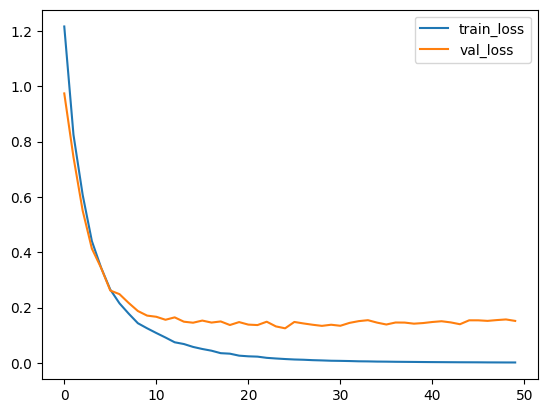

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'],label = 'train_loss')
plt.plot(history.history['val_loss'],label = 'val_loss')
plt.legend()
plt.show()


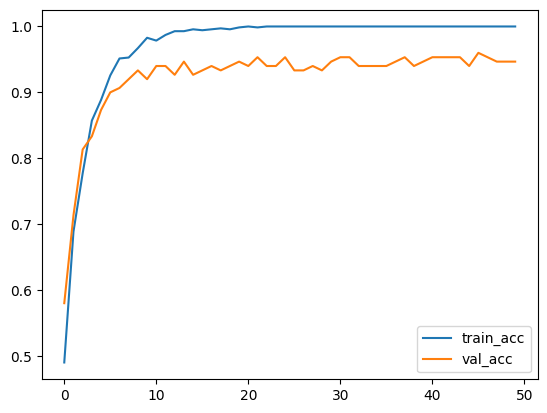

In [18]:
plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()


In [19]:
train_loss,train_acc = model.evaluate(X_train,y_train)
print(train_loss, train_acc)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0015  
0.0014531291089951992 1.0


In [20]:
val_loss,val_acc = model.evaluate(X_val,y_val)
print(val_loss,val_acc)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9467 - loss: 0.1520 
0.1519617736339569 0.9466666579246521


In [21]:
test_loss,test_acc = model.evaluate(X_test,y_test)
print(test_loss, test_acc)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8800 - loss: 0.7061 
0.7060686945915222 0.8799999952316284


In [22]:
import tensorflow as tf
import numpy as np


In [23]:
logits = model.predict(X_test)

probabilities = tf.nn.softmax(logits).numpy()
y_pred_classes = np.argmax(probabilities,axis=1)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [24]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_classes)


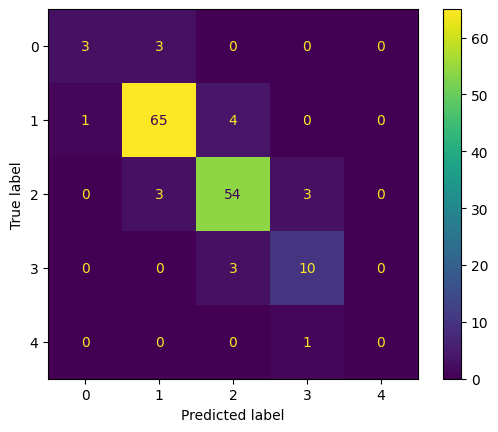

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
